In [ ]:
import matplotlib.pyplot as plt
import mrcfile
import numpy as np
import torch
from scipy.spatial.transform import Rotation
from torch_fourier_slice.project import project_3d_to_2d

from panther_em.utils.project_polar import get_polar_projections_from_volume
from panther_em.utils.warp_transforms import (
    warp_offset_polar_inverse,
)

In [2]:
volume_path = "/Users/mgiammar/Documents/tt2DTM/scratch_files/data/lsu.mrc"
volume = mrcfile.read(volume_path)
volume.shape, type(volume)

((512, 512, 512), numpy.ndarray)

In [11]:
phi = np.linspace(0, 180, 37, endpoint=False)
theta = np.linspace(0, 180, 37, endpoint=False)
psi = np.zeros_like(phi)

rot_matrix = Rotation.from_euler(
    "ZYZ", np.vstack((phi, theta, psi)).T, degrees=True
).as_matrix()

In [ ]:
projections = get_polar_projections_from_volume(
    volume,
    phi=phi,
    theta=theta,
)
projections.shape

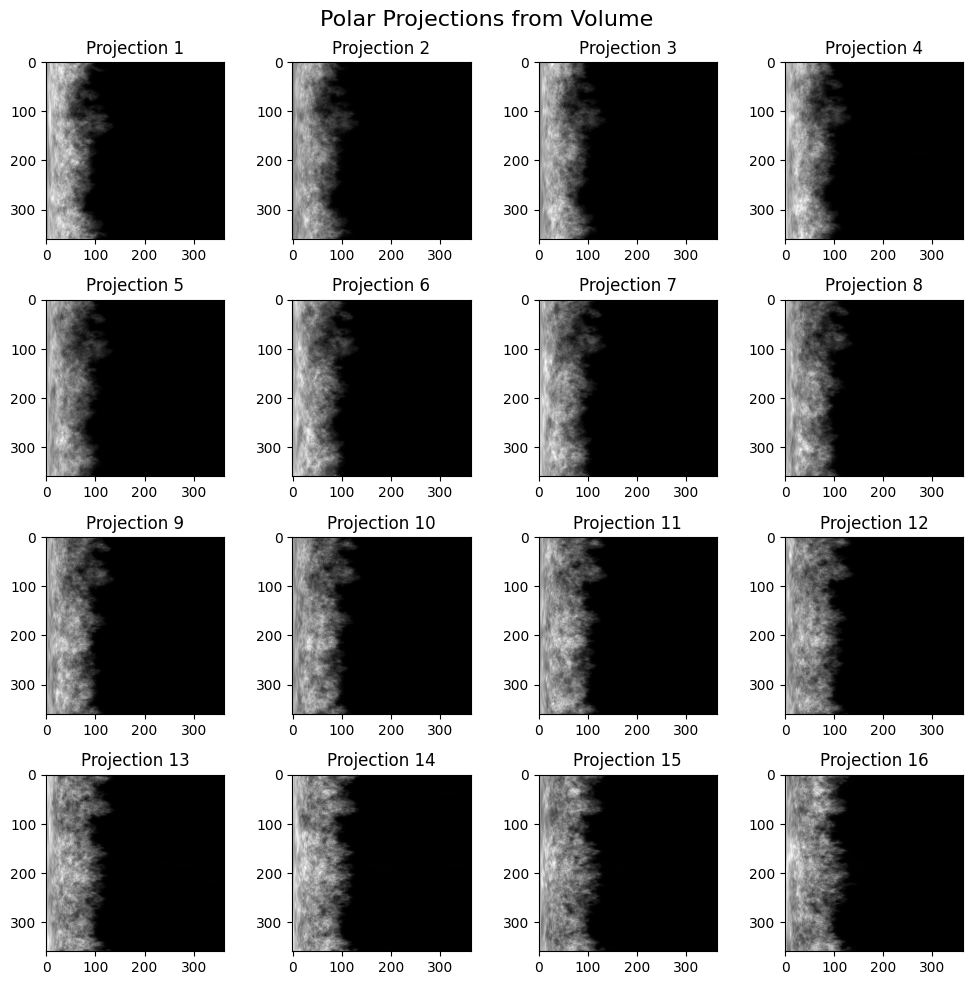

In [22]:
# Plot the first 16 projections
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(projections[i], cmap="gray")
    ax.set_title(f"Projection {i + 1}")

fig.suptitle("Polar Projections from Volume", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
inverse_projections = warp_offset_polar_inverse(
    projections,
    output_shape=(volume.shape[1], volume.shape[2]),
)

inverse_projections.shape

(37, 512, 512)

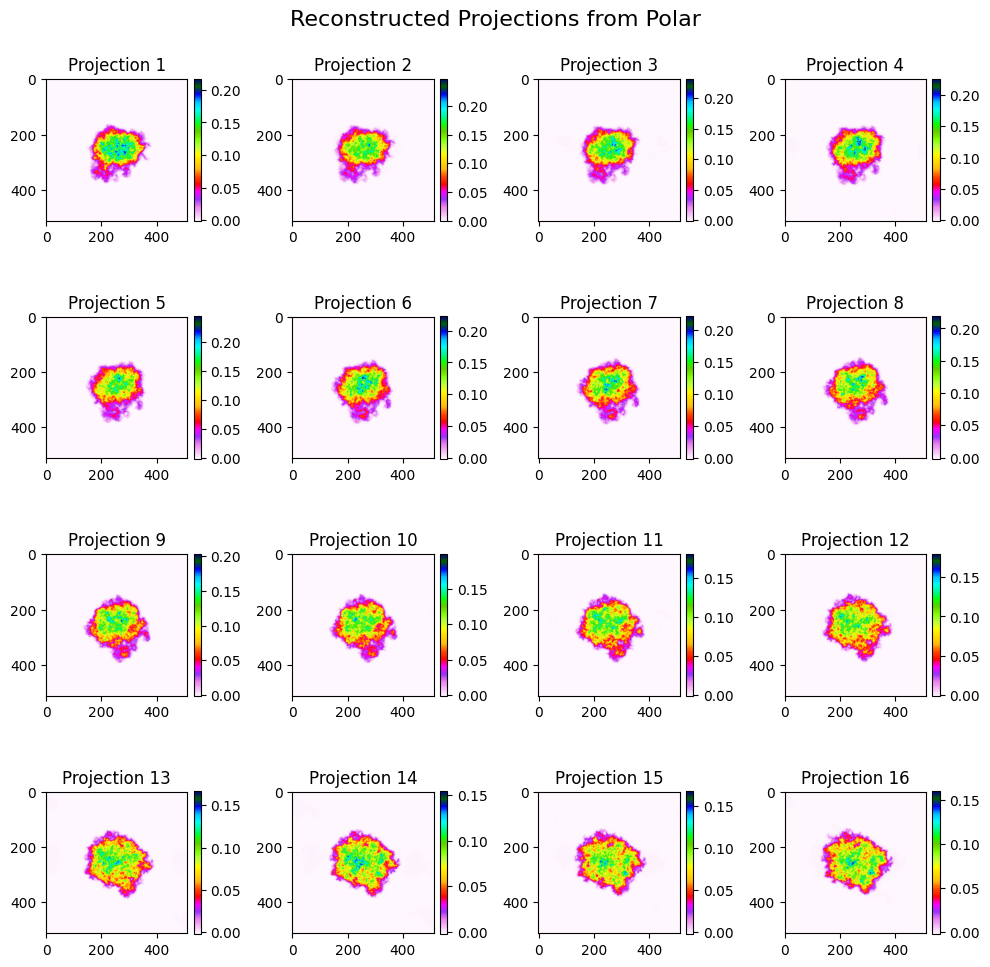

In [21]:
# Plot the first 16 reinverted projections
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.ravel()):
    im = ax.imshow(inverse_projections[i], cmap="gist_ncar_r")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(f"Projection {i + 1}")
fig.suptitle("Reconstructed Projections from Polar", fontsize=16)
plt.tight_layout()
plt.show()

In [16]:
# Plot the differences of the first 16 reinverted projections with their ground-truth
ground_truth_projections = project_3d_to_2d(
    volume=torch.from_numpy(volume), rotation_matrices=torch.from_numpy(rot_matrix)
)
ground_truth_projections.shape

torch.Size([37, 512, 512])

/var/folders/8h/_cpjhg310jsd2txc_9mr7hg80000gn/T/ipykernel_50620/1562109206.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  diff = ground_truth_projections - inverse_projections


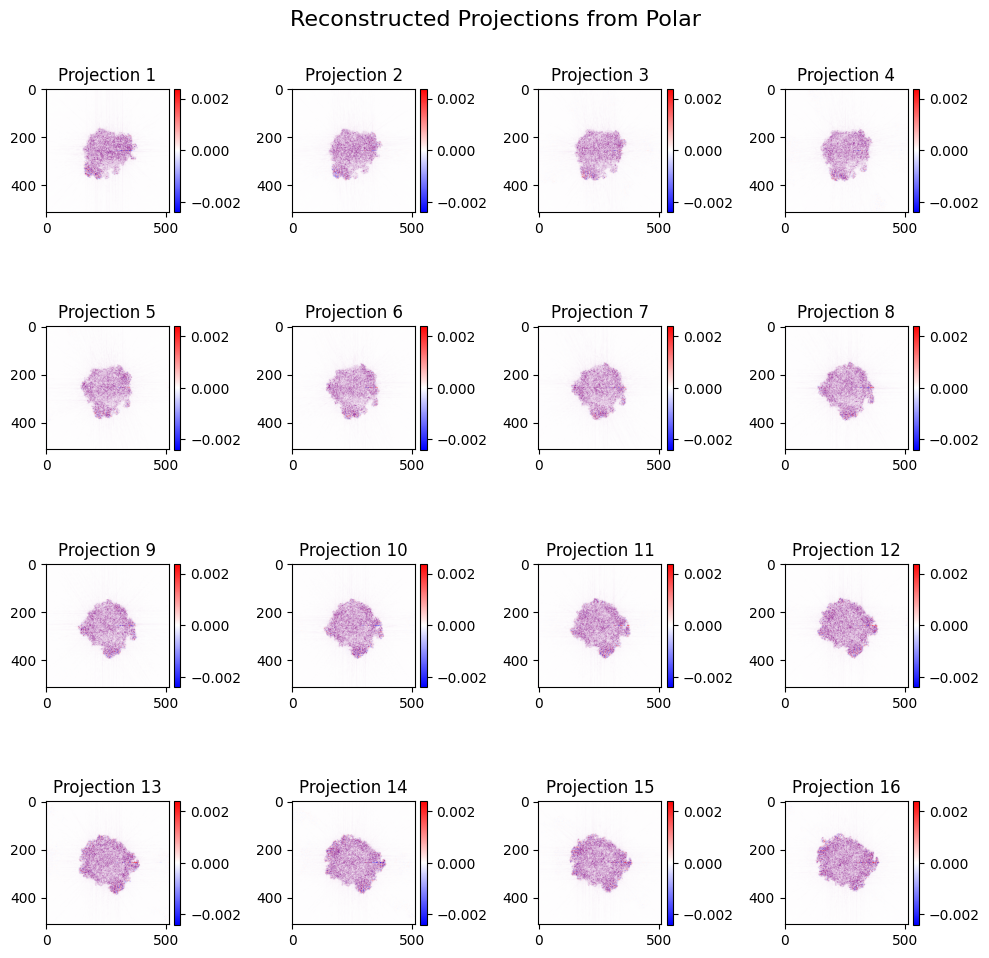

In [20]:
diff = ground_truth_projections - inverse_projections
max_diff = diff.abs().max() * 0.1

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.ravel()):
    im = ax.imshow(diff[i], cmap="bwr", vmin=-max_diff, vmax=max_diff)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(f"Projection {i + 1}")
fig.suptitle("Reconstructed Projections from Polar", fontsize=16)
plt.tight_layout()
plt.show()